# Part 2a: Creating and exporting the input files for the process-based model

## Introduction
This notebook builds all input files needed to calibrate and run the SuperflexPy process-based model. Forcing data (precipitation, temperature, PET) and observed streamflow are extracted from EStreams for each catchment group and saved as NumPy arrays under `data/models/input/`. The HRU permeability weight dictionaries — `perm_areas.npy` (regional), `perm_areasglobal.npy`, `perm_areascontinental.npy`, and `perm_areas_random*.npy` — are also computed and saved here. Two time-window subsets are produced: `subset_2001_2015` for space-time validation, and `subset_1988_2001` for space (calibration) evaluation.

For the **Garonne catchments**, a precipitation correction is derived and applied to account for the systematic underestimation of high-elevation precipitation in EStreams. The correction factor `k_pre` is estimated from an elevation-based regression against CAMELS-FR long-term mean precipitation: `k_pre = exp(0.0107 + 2.46×10⁻⁴ × elevation_mean)`. The corrected climatology file `garonne_clim_with_kpre.csv` is saved to `results/precipitation_correction/` and reused in the LSTM input preparation (Part-2b LSTM).

Alongside the other notebooks, it covers all the analysis performed in: "Assessing the Impact of Geological Map Detail on Process-Based and Data-Driven Hydrological Models" by do Nascimento et al. (2026).

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

## Requirements

**From EStreams dataset (v.1.4)** — https://doi.org/10.5281/zenodo.17598150 (Last access: 11 February 2025)

- `streamflow_gauges/estreams_gauging_stations.csv` — gauge metadata
- `time_series/` — daily streamflow and meteorological time series per gauge (NetCDF)

**From this repository (`../data/`):**

- `estreams_attributes_filtered_quality_geology_v01.csv` — catchment attributes pre-filtered for data quality (do Nascimento et al., 2025a; https://github.com/thiagovmdon/LSH-quality_geology, Last access: 11 February 2025)
- `estreams_geology_moselle_regional_attributes.csv` — regional-scale lithological fractions for 108 Moselle catchments (https://doi.org/10.5281/zenodo.18392387, Last access: 15 February 2025)
- `estreams_geology_garonne_regional_attributes.csv` — regional-scale lithological fractions for 22 Garonne catchments (produced by Part-0)
- `network_estreams_moselle_108_gauges.csv` — 108 Moselle study gauges and group assignments (produced by Part-1a Moselle)
- `network_estreams_garonne_22_gauges.csv` — 22 Garonne study gauges and group assignments (produced by Part-1b Garonne)
- CAMELS-FR climatic statistics (`CAMELS_FR_climatic_statistics.csv`) — used to derive the Garonne precipitation correction via regression against EStreams long-term means. Delaigue, O., et al. (2025). CAMELS-FR dataset: a large-sample hydroclimatic dataset for France. Earth Syst. Sci. Data, 17, 1461–1479. https://doi.org/10.5194/essd-17-1461-2025

**Produced by this notebook:**

- `../data/models/input/subset_2001_2015/inputs.npy` — forcing and runoff arrays indexed by group and catchment (space-time evaluation period)
- `../data/models/input/subset_2001_2015/observations.npy` — observed streamflow arrays
- `../data/models/input/subset_2001_2015/perm_areas.npy` — regional-scale HRU weights (high/medium/low permeability fractions) per catchment
- `../data/models/input/subset_2001_2015/perm_areasglobal.npy` — global-scale HRU weights
- `../data/models/input/subset_2001_2015/perm_areascontinental.npy` — continental-scale HRU weights
- `../data/models/input/subset_2001_2015/perm_areas_random*.npy` — randomised HRU weights (7 realisations for Moselle, 2 for Garonne)
- Same set of files under `subset_1988_2001/` for the space (calibration) evaluation period
- Additional arrays: `areas.npy`, `quality_masks.npy`, `rootdepth_mean.npy`, `waterdeficit_mean.npy`, `prec_mean.npy`
- `../results/precipitation_correction/garonne_clim_with_kpre.csv` — Garonne catchment climatology with derived `k_pre` elevation-based precipitation correction factors (reused by Part-2b LSTM)


## Import modules

In [1]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm
from utils.functions import find_max_unique_rows

## Configurations

In [2]:
# Path to where the EStreams dataset is stored
# Windows
path_estreams = r'/Users/nascimth/Documents/data/EStreams'

## Import data

In [3]:
# Read the gauges network metadata (from EStreams):
network_estreams = pd.read_csv(path_estreams+'/streamflow_gauges/estreams_gauging_stations.csv', encoding='utf-8')
network_estreams.set_index("basin_id", inplace = True)

# Attributes already filtered from EStreams previously in do Nascimento et al. (2025a):
estreams_attributes = pd.read_csv('../data/estreams_attributes_filtered_quality_geology_v01.csv', encoding='utf-8')
estreams_attributes.set_index("basin_id", inplace = True)

# Geological attributes (regional scale). Same ones provided in do Nascimento et al. (2025a):
geology_regional_31_classes_moselle = pd.read_csv("../data/estreams_geology_moselle_regional_attributes.csv", encoding='utf-8')
geology_regional_31_classes_moselle.set_index("basin_id", inplace = True)

# Geological attributes (regional scale) for the Garonne (new):
geology_regional_18_classes_garonne = pd.read_csv("../data/estreams_geology_garonne_regional_attributes.csv", encoding='utf-8')
geology_regional_18_classes_garonne.set_index("basin_id", inplace = True)


## Preprocessing

### Network data organization

In [4]:
# Make some adjusts in the data
# Convert 'date_column' and 'time_column' to datetime
network_estreams['start_date'] = pd.to_datetime(network_estreams['start_date'])
network_estreams['end_date'] = pd.to_datetime(network_estreams['end_date'])

# Convert to list both the nested_catchments and the duplicated_suspect columns
network_estreams['nested_catchments'] = network_estreams['nested_catchments'].apply(lambda x: x.strip("[]").replace("'", "").split(", "))

# Remove the brackets and handle NaN values
network_estreams['duplicated_suspect'] = network_estreams['duplicated_suspect'].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x)
 
nested_catchments = pd.DataFrame(network_estreams['nested_catchments'])

# Now we add the outlet to the list (IF it was not before):
# Ensure that the basin_id is in the nested_catchments
for basin_id in nested_catchments.index:
    if basin_id not in nested_catchments.at[basin_id, 'nested_catchments']:
        nested_catchments.at[basin_id, 'nested_catchments'].append(basin_id)


# Convert to list both the nested_catchments and the duplicated_suspect columns
estreams_attributes['nested_catchments'] = estreams_attributes['nested_catchments'].apply(lambda x: x.strip("[]").replace("'", "").split(", "))

# Remove the brackets and handle NaN values
estreams_attributes['duplicated_suspect'] = estreams_attributes['duplicated_suspect'].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x)

estreams_attributes.sort_index(inplace = True) 

### Geological data organization

In [5]:
# Moselle
# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": ["lit_fra_Alluvium", 'lit_fra_Coal', 'lit_fra_Conglomerate', 'lit_fra_Gravel and sand',
             'lit_fra_Sand', 'lit_fra_Sand and gravel', 'lit_fra_Sandstone and conglomerate', 'lit_fra_Sandstone'
        ],
    
    "medium": ['lit_fra_Limestone', 'lit_fra_Sandstone and marl', 'lit_fra_Sandstone and schist',
              'lit_fra_Sandstone, conglomerate and marl',

              'lit_fra_Arkose', 'lit_fra_Dolomite rock', 'lit_fra_Limestone and marl', 'lit_fra_Marl', 
             'lit_fra_Marl and dolomite', 'lit_fra_Marl and limestone', 'lit_fra_Marl and sandstone',
               'lit_fra_Sandstone and siltstone', 'lit_fra_Sandstone, siltstone and schist', 
              'lit_fra_Schist and sandstone', 'lit_fra_Silt',  'lit_fra_Silt and schist', 'lit_fra_Siltstone, sandstone and schist'
              
             ],
    
    "low": ['lit_fra_Cristallin basement', 'lit_fra_Plutonic rock',  'lit_fra_Quarzite',
                    'lit_fra_Schist','lit_fra_Volcanic rock' 
                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional_31_classes_moselle[f'area_perm_{permeability_class}'] = geology_regional_31_classes_moselle[columns].sum(axis=1)

# Drop unnecessary columns
geology_regional_31_classes_moselle = geology_regional_31_classes_moselle[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional_31_classes_moselle.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]

# Display the updated DataFrame
geology_regional_31_classes_moselle

geology_regional_31_classes_moselle["baseflow_index"] = estreams_attributes["baseflow_index"]

In [6]:
# Garonne
# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": [ "lit_fra_Alluvium",
             'lit_fra_Sand, gravel and pebbles'    
        ],
    
    "medium": ['lit_fra_Carbonate rocks', 
               'lit_fra_Limestones', 
               'lit_fra_Limestones, sandstones and gravels', 
               'lit_fra_Limestones, sandstones and marls', 
               'lit_fra_Molasses and clays',  
               'lit_fra_Sands and clays',
                'lit_fra_Sedimentary rocks',
               'lit_fra_Sediments mesosoics',
            'lit_fra_Schists, gneisses, granites', 
             ],
    
    "low": ['lit_fra_Impermeable', 
            'lit_fra_Inland water', 
            'lit_fra_Magmatic rocks', 
            'lit_fra_Massif', 
            'lit_fra_Plutonic rocks',
            'lit_fra_Shales',
            'lit_fra_Granitoids',
                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional_18_classes_garonne[f'area_perm_{permeability_class}'] = geology_regional_18_classes_garonne[columns].sum(axis=1)



# Drop unnecessary columns
geology_regional_18_classes_garonne = geology_regional_18_classes_garonne[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional_18_classes_garonne.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]

### Attributes

In [7]:
# Moselle
# Concatenation
estreams_attributes[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional_31_classes_moselle[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]

estreams_attributes["perm_high_glob2"] = estreams_attributes["perm_high_glob"]
estreams_attributes["perm_medium_glob2"] = estreams_attributes["perm_medium_glob"] + estreams_attributes["perm_low_glob"]
estreams_attributes["perm_low_glob2"] = estreams_attributes["perm_verylow_glob"]

estreams_attributes["perm_high_cont2"] = estreams_attributes["perm_high_cont"]
estreams_attributes["perm_medium_cont2"] = estreams_attributes["perm_medium_cont"] + estreams_attributes["perm_low_cont"]
estreams_attributes["perm_low_cont2"] = estreams_attributes["perm_verylow_cont"]


for basin_id in estreams_attributes.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes.loc[basin_id, "perm_high_regi"] / 100
    v2 = estreams_attributes.loc[basin_id, "perm_medium_regi"] / 100
    v3 = estreams_attributes.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes.loc[basin_id, "perm_high_regi"] = v1 * 100
    estreams_attributes.loc[basin_id, "perm_medium_regi"] = v2 * 100
    estreams_attributes.loc[basin_id, "perm_low_regi"] = v3 * 100


for basin_id in estreams_attributes.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes.loc[basin_id, "perm_high_glob2"] / 100
    v2 = estreams_attributes.loc[basin_id, "perm_medium_glob2"] / 100
    v3 = estreams_attributes.loc[basin_id, "perm_low_glob2"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes.loc[basin_id, "perm_high_glob2"] = v1 * 100
    estreams_attributes.loc[basin_id, "perm_medium_glob2"] = v2 * 100
    estreams_attributes.loc[basin_id, "perm_low_glob2"] = v3 * 100

for basin_id in estreams_attributes.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes.loc[basin_id, "perm_high_cont2"] / 100
    v2 = estreams_attributes.loc[basin_id, "perm_medium_cont2"] / 100
    v3 = estreams_attributes.loc[basin_id, "perm_low_cont2"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes.loc[basin_id, "perm_high_cont2"] = v1 * 100
    estreams_attributes.loc[basin_id, "perm_medium_cont2"] = v2 * 100
    estreams_attributes.loc[basin_id, "perm_low_cont2"] = v3 * 100

In [8]:
# Garonne
# Concatenation
estreams_attributes_garonne = estreams_attributes.copy()

estreams_attributes_garonne[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional_18_classes_garonne[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]
estreams_attributes_garonne["perm_high_glob2"] = estreams_attributes_garonne["perm_high_glob"]
estreams_attributes_garonne["perm_medium_glob2"] = estreams_attributes_garonne["perm_medium_glob"] + estreams_attributes_garonne["perm_low_glob"]
estreams_attributes_garonne["perm_low_glob2"] = estreams_attributes_garonne["perm_verylow_glob"]

estreams_attributes_garonne["perm_high_cont2"] = estreams_attributes_garonne["perm_high_cont"]
estreams_attributes_garonne["perm_medium_cont2"] = estreams_attributes_garonne["perm_medium_cont"] + estreams_attributes_garonne["perm_low_cont"]
estreams_attributes_garonne["perm_low_cont2"] = estreams_attributes_garonne["perm_verylow_cont"]

for basin_id in estreams_attributes_garonne.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes_garonne.loc[basin_id, "perm_high_regi"] / 100
    v2 = estreams_attributes_garonne.loc[basin_id, "perm_medium_regi"] / 100
    v3 = estreams_attributes_garonne.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes_garonne.loc[basin_id, "perm_high_regi"] = v1 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_medium_regi"] = v2 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_low_regi"] = v3 * 100


for basin_id in estreams_attributes_garonne.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes_garonne.loc[basin_id, "perm_high_glob2"] / 100
    v2 = estreams_attributes_garonne.loc[basin_id, "perm_medium_glob2"] / 100
    v3 = estreams_attributes_garonne.loc[basin_id, "perm_low_glob2"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes_garonne.loc[basin_id, "perm_high_glob2"] = v1 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_medium_glob2"] = v2 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_low_glob2"] = v3 * 100

for basin_id in estreams_attributes_garonne.index.tolist():

    # Extract and divide by 100
    v1 = estreams_attributes_garonne.loc[basin_id, "perm_high_cont2"] / 100
    v2 = estreams_attributes_garonne.loc[basin_id, "perm_medium_cont2"] / 100
    v3 = estreams_attributes_garonne.loc[basin_id, "perm_low_cont2"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    estreams_attributes_garonne.loc[basin_id, "perm_high_cont2"] = v1 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_medium_cont2"] = v2 * 100
    estreams_attributes_garonne.loc[basin_id, "perm_low_cont2"] = v3 * 100


### Further filter of the network

In [9]:
# Moselle:
# First we define the outlet of the Moselle to be used
outlets = ["DEBU1959"]
nested_cats_df = nested_catchments.loc[outlets, :]

# Now we save our dataframes in a dictionary of dataframes. One dataframe for each watershed. 

nested_cats_filtered = find_max_unique_rows(nested_cats_df)                                  # Filter only the catchemnts using the function stated before
nested_cats_filtered_df = nested_catchments.loc[nested_cats_filtered, :]                     # Here we filter the catchemnts for the list (again, after we apply our function):

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_dfs = {}
for catchment in tqdm.tqdm(nested_cats_filtered):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_dfs[catchment] = cat_clip

# Here we can save the length of each watershed (number of nested catchemnts)
catchment_lens = pd.DataFrame(index = estreams_attributes_dfs.keys())
for catchment, data in estreams_attributes_dfs.items():
    catchment_lens.loc[catchment, "len"] = len(data)

# Now we can filter it properly:
nested_cats_filtered_abovevalue = catchment_lens[catchment_lens.len >= 10]

# # Here we filter the catchemnts for the list (again, after we apply our function):
nested_cats_filtered_abovevalue_df = nested_catchments.loc[nested_cats_filtered_abovevalue.index, :]

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_dfs = {}

for catchment in tqdm.tqdm(nested_cats_filtered_abovevalue_df.index):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_abovevalue_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_dfs[catchment] = cat_clip

estreams_attributes_clipped = estreams_attributes_dfs["DEBU1959"]
catchments_ids = estreams_attributes_clipped.index.tolist()

100%|██████████| 1/1 [00:00<00:00, 313.22it/s]


In [10]:
# Garonne:
# First we define the outlet of the Moselle to be used
outlets = ["FR001604"]
nested_cats_df = nested_catchments.loc[outlets, :]

# Now we save our dataframes in a dictionary of dataframes. One dataframe for each watershed. 

nested_cats_filtered = find_max_unique_rows(nested_cats_df)                                  # Filter only the catchemnts using the function stated before
nested_cats_filtered_df = nested_catchments.loc[nested_cats_filtered, :]                     # Here we filter the catchemnts for the list (again, after we apply our function):

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_garonne_dfs = {}
for catchment in tqdm.tqdm(nested_cats_filtered):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes_garonne.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes_garonne.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_garonne_dfs[catchment] = cat_clip

# Here we can save the length of each watershed (number of nested catchemnts)
catchment_lens = pd.DataFrame(index = estreams_attributes_garonne_dfs.keys())
for catchment, data in estreams_attributes_garonne_dfs.items():
    catchment_lens.loc[catchment, "len"] = len(data)

# Now we can filter it properly:
nested_cats_filtered_abovevalue = catchment_lens[catchment_lens.len >= 10]

# # Here we filter the catchemnts for the list (again, after we apply our function):
nested_cats_filtered_abovevalue_df = nested_catchments.loc[nested_cats_filtered_abovevalue.index, :]

# Store the variables for the selected catchments in a list of dataframes now for only the ones above 20 cats:
estreams_attributes_garonne_dfs = {}

for catchment in tqdm.tqdm(nested_cats_filtered_abovevalue_df.index):
    # Retrieve the nested list of catchments for the current catchment
    nested_clip = nested_cats_filtered_abovevalue_df.loc[catchment, 'nested_catchments']
    
    # Filter values to include only those that exist in the index of estreams_attributes
    nested_clip = [value for value in nested_clip if value in estreams_attributes_garonne.index]
    
    # Filter the estreams_attributes DataFrame based on the filtered nested_clip
    cat_clip = estreams_attributes_garonne.loc[nested_clip, :]
    
    # Store the resulting DataFrame in the dictionary
    estreams_attributes_garonne_dfs[catchment] = cat_clip


estreams_attributes_garonne_clipped = estreams_attributes_garonne_dfs["FR001604"]
catchments_garonne_ids = estreams_attributes_garonne_clipped.index.tolist()

100%|██████████| 1/1 [00:00<00:00, 500.27it/s]


## Data export
### Moselle

In [ ]:
# Initialize the dictionary
inputs = {}
observations = {}
areas = {}
perm_areas = {}
quality_masks = {}
rootdepth_mean = {}
waterdeficit_mean = {}
perm_areasglobal = {}
perm_areascontinental = {}
prec_mean = {}

# Function to compute S_dem per water year
def compute_S_dem(group):
    group = group.copy()
    group.iloc[0, group.columns.get_loc('S_dem(t-1)')] = 0
    group.iloc[0, group.columns.get_loc('S_dem(t)')] = max(
        0, group.iloc[0]['S_dem(t-1)'] + (group.iloc[0]['pet_mean'] - group.iloc[0]['p_mean'])
    )

    for i in range(1, len(group)):
        group.iloc[i, group.columns.get_loc('S_dem(t-1)')] = group.iloc[i - 1]['S_dem(t)']
        group.iloc[i, group.columns.get_loc('S_dem(t)')] = max(
            0, group.iloc[i]['S_dem(t-1)'] + (group.iloc[i]['pet_mean'] - group.iloc[i]['p_mean'])
        )

    return group


for basin_id in tqdm.tqdm(catchments_ids):
    
    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

    area = network_estreams.loc[basin_id, "area_estreams"]

    data["Q"] = data.loc[:, "q_mean"]
    data["Q"] = (data.Q * 86400 * 1000) / (area * 1000000)

    # Define the subset to be used:
    #data = data.loc["1988":"2001", :]
    data = data.loc["2000-10-01":"2015-09-30"]


    # Interpolate when needed:
    data['pet_mean'] = data['pet_mean'].interpolate()
    data['t_mean'] = data['t_mean'].interpolate()
    data['p_mean'] = data['p_mean'].interpolate()


    data_wd = data.copy()
    data_wd.index = pd.to_datetime(data_wd.index)

    # Define water year (Oct 1 to Sept 30)

    data_wd['water_year'] = np.where(data_wd.index.month >= 10, data_wd.index.year + 1, data_wd.index.year)
    data_wd['S_dem(t-1)'] = np.nan
    data_wd['S_dem(t)'] = np.nan

    ## Apply computation per water year
    data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
    
    # Compute the 75% quantile of 'S_dem(t)' per water year
    S_dem_75_per_year = data_wd.groupby('water_year')['S_dem(t)'].max()
    S_dem_75_per_year = S_dem_75_per_year.quantile(0.75)

    # Save the variables:
    Q_obs = data.loc[:, "Q"].values
    P = data.loc[:, "p_mean"].values
    E = data.loc[:, "pet_mean"].values
    T = data.loc[:, "t_mean"].values
    quality =  (pd.isna(Q_obs)).astype(int)

    inputs[basin_id] = [P, T, E]
    observations[basin_id] = Q_obs
    areas[basin_id] = area
    perm_areas[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_regi"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_regi"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_regi"] / 100, 2)]
    
    perm_areasglobal[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_glob2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_glob2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_glob2"] / 100, 2)]
    
    perm_areascontinental[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_cont2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_cont2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_cont2"] / 100, 2)]

    quality_masks[basin_id] = quality
    rootdepth_mean[basin_id] = estreams_attributes.loc[basin_id, "root_dep_mean"]
    waterdeficit_mean[basin_id] = np.float64(round(S_dem_75_per_year, 1))
    prec_mean[basin_id] = estreams_attributes.loc[basin_id, "p_mean"]

  0%|          | 0/152 [00:00<?, ?it/s]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_76105/1266584438.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  1%|          | 1/152 [00:01<02:32,  1.01s/it]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_76105/1266584438.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

In [10]:
import numpy as np
import os as os
# Number of random versions you want
n_random_sets = 7

# Number of components (high, medium, low)
n_components = 3

# Initialize the containers
perm_areas_random = {}

# Save the dictionaries
path_inputs1 = r'../data/models/input/subset_2001_2015'
path_inputs2 = r'../data/models/input/subset_1988_2001'


# Loop through each random set
for i in range(1, n_random_sets + 1):
    seed = 100 + i  # you can choose your own seed pattern
    np.random.seed(seed)

    perm_dict = {}
    for basin_id in catchments_ids:
        # Generate 3 random positive numbers
        r = np.random.rand(n_components)
        # Normalize to make them sum to 1
        r = r / r.sum()
        # Round if you want consistent formatting (e.g., 2 decimals)
        perm_dict[basin_id] = np.round(r, 2).tolist()

    # Save to a named variable like perm_areas_random01, etc.
    perm_areas_random[f'perm_areas_random{i:02d}'] = perm_dict
    
    # Save dictionary as .npy
    np.save(os.path.join(path_inputs1, f'perm_areas_random{i:02d}.npy'), perm_dict)
    np.save(os.path.join(path_inputs2, f'perm_areas_random{i:02d}.npy'), perm_dict)

In [11]:
# Save the dictionaries
path_inputs = r'../data/models/input/subset_2001_2015'

np.save(path_inputs+'//inputs.npy', inputs)
np.save(path_inputs+'//observations.npy', observations)
np.save(path_inputs+'//areas.npy', areas)
np.save(path_inputs+'//perm_areas.npy', perm_areas)
np.save(path_inputs+'//quality_masks.npy', quality_masks)
np.save(path_inputs+'//rootdepth_mean.npy', rootdepth_mean)
np.save(path_inputs+'//waterdeficit_mean.npy', waterdeficit_mean)
np.save(path_inputs+'//perm_areasglobal.npy', perm_areasglobal)
np.save(path_inputs+'//perm_areascontinental.npy', perm_areascontinental)
np.save(path_inputs+'//prec_mean.npy', prec_mean)

In [13]:
# Initialize the dictionary
inputs = {}
observations = {}
areas = {}
perm_areas = {}
quality_masks = {}
rootdepth_mean = {}
waterdeficit_mean = {}
perm_areasglobal = {}
perm_areascontinental = {}
prec_mean = {}

# Function to compute S_dem per water year
def compute_S_dem(group):
    group = group.copy()
    group.iloc[0, group.columns.get_loc('S_dem(t-1)')] = 0
    group.iloc[0, group.columns.get_loc('S_dem(t)')] = max(
        0, group.iloc[0]['S_dem(t-1)'] + (group.iloc[0]['pet_mean'] - group.iloc[0]['p_mean'])
    )

    for i in range(1, len(group)):
        group.iloc[i, group.columns.get_loc('S_dem(t-1)')] = group.iloc[i - 1]['S_dem(t)']
        group.iloc[i, group.columns.get_loc('S_dem(t)')] = max(
            0, group.iloc[i]['S_dem(t-1)'] + (group.iloc[i]['pet_mean'] - group.iloc[i]['p_mean'])
        )

    return group


for basin_id in tqdm.tqdm(catchments_ids):
    
    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

    area = network_estreams.loc[basin_id, "area_estreams"]

    data["Q"] = data.loc[:, "q_mean"]
    data["Q"] = (data.Q * 86400 * 1000) / (area * 1000000)

    # Define the subset to be used:
    data = data.loc["1988-10-01":"2001-09-30", :]
    #data = data.loc["2001-10-01":"2015-09-30"]


    # Interpolate when needed:
    data['pet_mean'] = data['pet_mean'].interpolate()
    data['t_mean'] = data['t_mean'].interpolate()
    data['p_mean'] = data['p_mean'].interpolate()


    data_wd = data.copy()
    data_wd.index = pd.to_datetime(data_wd.index)

    # Define water year (Oct 1 to Sept 30)

    data_wd['water_year'] = np.where(data_wd.index.month >= 10, data_wd.index.year + 1, data_wd.index.year)
    data_wd['S_dem(t-1)'] = np.nan
    data_wd['S_dem(t)'] = np.nan

    # Apply computation per water year
    data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
    
    # Compute the 75% quantile of 'S_dem(t)' per water year
    S_dem_75_per_year = data_wd.groupby('water_year')['S_dem(t)'].max()
    S_dem_75_per_year = S_dem_75_per_year.quantile(0.75)

    # Save the variables:
    Q_obs = data.loc[:, "Q"].values
    P = data.loc[:, "p_mean"].values
    E = data.loc[:, "pet_mean"].values
    T = data.loc[:, "t_mean"].values
    quality =  (pd.isna(Q_obs)).astype(int)

    inputs[basin_id] = [P, T, E]
    observations[basin_id] = Q_obs
    areas[basin_id] = area
    perm_areas[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_regi"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_regi"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_regi"] / 100, 2)]
    
    perm_areasglobal[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_glob2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_glob2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_glob2"] / 100, 2)]
    
    perm_areascontinental[basin_id] = [round(estreams_attributes.loc[basin_id, "perm_high_cont2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_medium_cont2"] / 100, 2), 
                            round(estreams_attributes.loc[basin_id, "perm_low_cont2"] / 100, 2)]

    quality_masks[basin_id] = quality
    rootdepth_mean[basin_id] = estreams_attributes.loc[basin_id, "root_dep_mean"]
    waterdeficit_mean[basin_id] = np.float64(round(S_dem_75_per_year, 1))
    prec_mean[basin_id] = estreams_attributes.loc[basin_id, "p_mean"]

  0%|          | 0/152 [00:00<?, ?it/s]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_76105/2702099963.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  1%|          | 1/152 [00:00<02:05,  1.20it/s]/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_76105/2702099963.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

In [14]:
# Save the dictionaries
path_inputs = r'../data/models/input/subset_1988_2001'

np.save(path_inputs+'//inputs.npy', inputs)
np.save(path_inputs+'//observations.npy', observations)
np.save(path_inputs+'//areas.npy', areas)
np.save(path_inputs+'//perm_areas.npy', perm_areas)
np.save(path_inputs+'//quality_masks.npy', quality_masks)
np.save(path_inputs+'//rootdepth_mean.npy', rootdepth_mean)
np.save(path_inputs+'//waterdeficit_mean.npy', waterdeficit_mean)
np.save(path_inputs+'//perm_areasglobal.npy', perm_areasglobal)
np.save(path_inputs+'//perm_areascontinental.npy', perm_areascontinental)
np.save(path_inputs+'//prec_mean.npy', prec_mean)

### Garonne

### Precipitation issues

In [11]:
garonne_clim = pd.read_csv("../results/precipitation_correction/garonne_clim.csv")
moselle_clim = pd.read_csv("../results/precipitation_correction/moselle_clim.csv")

moselle_clim.set_index("Unnamed: 0", inplace=True)
moselle_clim.index.name="basin_id"

garonne_clim.set_index("Unnamed: 0", inplace=True)
garonne_clim.index.name="basin_id"

In [12]:
import os as os

In [13]:
# Data from CAMELS-FR
camels_fr_pmean = pd.read_csv("/Users/nascimth/Documents/CAMELS_FR_attributes/time_series_statistics/CAMELS_FR_climatic_statistics.csv",
sep=";")

camels_fr_pmean.set_index("sta_code_h3", inplace=True)

# Here we check which basins intersect using the gauge_id
data_dir = "/Users/nascimth/Documents/CAMELS_FR_time_series/daily/"
gantt_segments = []

# List of existing basin files (without the .csv extension)
existing_files = {
    f.replace("CAMELS_FR_tsd_", "").replace(".csv", "")
    for f in os.listdir(data_dir)
    if f.startswith("CAMELS_FR_tsd_") and f.endswith(".csv")
}

# Filter only gauges that have a corresponding CSV file
valid_gauges = [
    basin_id for basin_id in garonne_clim.gauge_id
    if basin_id in existing_files
]

print(f"Found {len(valid_gauges)} valid gauges with available files.")

# Here we filter to our overlaping basins
camels_fr_pmean = camels_fr_pmean.loc[valid_gauges, :]

camels_fr_pmean

Found 10 valid gauges with available files.


,cli_prec_mean,cli_pet_ou_mean,cli_pet_pe_mean,cli_pet_pm_mean,cli_prec_mean_yr,cli_pet_ou_yr,cli_pet_pe_yr,cli_pet_pm_yr,cli_temp_mean,cli_psol_frac_safran,...,cli_assync_pm,cli_prec_intensity,cli_prec_max,cli_prec_date_max,cli_prec_freq_high,cli_prec_dur_high,cli_prec_timing_high,cli_prec_freq_low,cli_prec_dur_low,cli_prec_timing_low
sta_code_h3,,,,,,,,,,,,,,,,,,,,,
O029531001,2.40426,2.08544,2.17951,1.87826,878,762,796,686,11.6,0.02417,...,0.25680,0.53265,74.7,1978-06-10,19.67308,1.21209,mam,240.26923,4.29200,jja
O055401001,3.03339,1.94116,2.09738,1.83629,1108,709,766,671,10.4,0.09197,...,0.22091,0.52262,105.2,1992-10-04,17.61538,1.22953,mam,216.73077,3.64725,son
O062401001,2.76643,2.05436,2.11894,1.83004,1010,750,774,668,11.5,0.03343,...,0.23631,0.50309,102.2,2000-06-10,19.34615,1.21498,mam,233.25000,4.01091,jja
O158461001,2.66111,2.06280,2.48059,2.04006,972,753,906,745,11.4,0.05101,...,0.28758,0.50624,108.9,2010-10-10,19.42308,1.23321,NaN,242.80769,4.24832,jja
O023402001,3.55368,1.77198,2.02530,1.76940,1298,647,740,646,8.9,0.18134,...,0.21100,0.49259,129.8,1992-10-04,18.09615,1.23007,mam,212.28846,3.50333,son
O074404001,3.07764,1.99409,2.08745,1.80965,1124,728,762,661,10.9,0.05619,...,0.23873,0.47708,107.6,2000-06-10,18.75000,1.20370,mam,226.17308,3.85228,jja
O144291002,3.22417,1.77991,2.29247,1.94076,1178,650,837,709,9.0,0.17700,...,0.28729,0.47910,108.8,1993-09-23,18.01923,1.25603,djf,219.09615,3.75759,jja
O149431003,3.22927,1.76004,2.20563,1.85681,1179,643,806,678,8.8,0.18997,...,0.28271,0.48935,112.2,1993-09-23,18.28846,1.24476,djf,221.34615,3.79743,jja
O149433001,3.06138,1.83985,2.28297,1.90576,1118,672,834,696,9.5,0.15140,...,0.28511,0.49193,110.2,1993-09-23,18.44231,1.23423,son,225.15385,3.86403,jja


In [14]:
# Initialize the dictionary
catchments_garonne_ids = garonne_clim.index.tolist()


for basin_id in tqdm.tqdm(catchments_garonne_ids):

    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

 
    data = data.loc["1988-10-01":"2015-09-30"]


    garonne_clim.loc[basin_id, "t_mean"] = np.mean(data['t_mean'])


# Initialize the dictionary
catchments_moselle_ids = moselle_clim.index.tolist()


for basin_id in tqdm.tqdm(catchments_moselle_ids):

    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

 
    data = data.loc["1988-10-01":"2015-09-30"]


    moselle_clim.loc[basin_id, "t_mean"] = np.mean(data['t_mean'])

100%|██████████| 92/92 [00:02<00:00, 42.72it/s]


In [17]:
garonne_clim_camels = garonne_clim.copy()

garonne_clim_camels.set_index("gauge_id", inplace=True)

garonne_clim_camels[["cli_prec_mean"]] = camels_fr_pmean[["cli_prec_mean"]]
garonne_clim_camels[["cli_temp_mean"]] = camels_fr_pmean[["cli_temp_mean"]]

garonne_clim_camels = garonne_clim_camels.loc[camels_fr_pmean.index.tolist()]

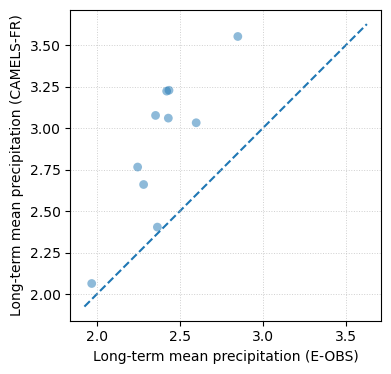

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))

# Scatter
ax.scatter(
    garonne_clim_camels.loc[:, "p_mean"],
    garonne_clim_camels.loc[:, "cli_prec_mean"],
    s=40,
    alpha=0.5,
    edgecolors="none",
    zorder=2
)

# 1:1 line
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
vmin = min(xmin, ymin)
vmax = max(xmax, ymax)

ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    linewidth=1.5,
    zorder=1
)

# Make axes equal
ax.set_aspect("equal", adjustable="box")

# Labels
ax.set_ylabel("Long-term mean precipitation (CAMELS-FR)")
ax.set_xlabel("Long-term mean precipitation (E-OBS)")


# Grid (light and behind points)
ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6, zorder=0)

# Tight layout
plt.tight_layout()

plt.savefig("../results/figs/figures/SI_biascorrection.png", dpi=300)
plt.show()


(0.0, 5.0)

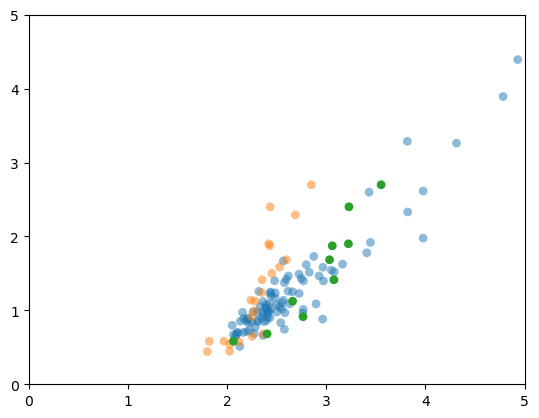

In [17]:
fig, ax = plt.subplots()

ax.scatter(
            moselle_clim.loc[:, "p_mean"],
            moselle_clim.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)


ax.scatter(
            garonne_clim.loc[:, "p_mean"],
            garonne_clim.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)



ax.scatter(
            garonne_clim_camels.loc[:, "cli_prec_mean"],
            garonne_clim_camels.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=1,
            zorder=1)

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

In [18]:
garonne_clim_camels

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,nse_rand,bfi_obs,bfi_r1comp,bfi_c1comp,bfi_g1comp,bfi_nogeo,...,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_rand,p_mean,ele_mt_mean,gauge_name,t_mean,cli_prec_mean,cli_temp_mean
gauge_id,,,,,,,,,,,,,,,,,,,,,
O029531001,0.697635,0.711753,0.721948,0.708220,0.730121,0.539423,0.636402,0.574418,0.624012,0.624724,...,0.897051,0.891340,0.893654,0.888284,2.365,411.430,O0295310,11.969463,2.40426,11.6
O055401001,0.685334,0.699813,0.702822,0.696487,0.716126,0.556167,0.558764,0.573878,0.623942,0.630287,...,1.291152,1.275334,1.260428,1.284879,2.599,671.291,O0554010,10.735842,3.03339,10.4
O062401001,0.690960,0.723777,0.735273,0.684688,0.728631,0.456656,0.625720,0.496957,0.592440,0.598371,...,0.827132,0.802795,0.799003,0.802478,2.246,475.752,O0624010,11.858859,2.76643,11.5
O158461001,0.730333,0.780502,0.776030,0.777302,0.721376,0.465276,0.508776,0.506442,0.546681,0.595770,...,1.298150,1.271059,1.274727,1.288056,2.282,559.939,O1584610,11.554390,2.66111,11.4
O023402001,0.540437,0.498590,0.568121,0.574346,0.452339,0.655594,0.667265,0.698444,0.594348,0.612460,...,1.860771,1.832182,1.835464,1.834416,2.850,1035.152,Le Ger Ã Aspet [2],9.110264,3.55368,8.9
O074404001,0.744501,0.740654,0.719153,0.698710,0.710849,0.560217,0.700905,0.663441,0.641699,0.634061,...,1.098579,1.088775,1.087034,1.097173,2.354,579.685,L'Arize au Mas-d'Azil,11.157343,3.07764,10.9
O144291002,0.716092,0.714494,0.731857,0.684775,0.731311,0.652251,0.570153,0.609677,0.615154,0.619351,...,1.447128,1.424509,1.402036,1.436035,2.421,1063.854,Le Grand Hers Ã Laroque-d'Olmes et au Peyrat,9.219512,3.22417,9.0
O149431003,0.547683,0.544578,0.555606,0.554618,0.543674,0.603356,0.664012,0.677279,0.632744,0.594153,...,1.557013,1.528955,1.531695,1.533939,2.435,1097.040,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,8.625799,3.22927,8.8
O149433001,0.657394,0.671578,0.682339,0.673129,0.667721,0.617747,0.654277,0.634912,0.626415,0.619819,...,1.448851,1.425873,1.402899,1.423393,2.431,940.039,Le Touyre Ã LÃ©ran,9.467105,3.06138,9.5


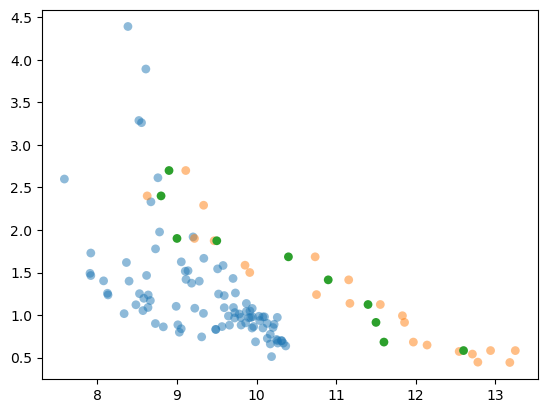

In [19]:
fig, ax = plt.subplots()

ax.scatter(
            moselle_clim.loc[:, "t_mean"],
            moselle_clim.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)


ax.scatter(
            garonne_clim.loc[:, "t_mean"],
            garonne_clim.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)



ax.scatter(
            garonne_clim_camels.loc[:, "cli_temp_mean"],
            garonne_clim_camels.loc[:, "qmean_obs"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=1,
            zorder=1)



In [20]:
garonne_clim_camels["k_p"] = garonne_clim_camels["cli_prec_mean"]/garonne_clim_camels["p_mean"]

garonne_clim_camels[["p_mean", "k_p"]]

,p_mean,k_p
gauge_id,,
O029531001,2.365,1.016600
O055401001,2.599,1.167137
O062401001,2.246,1.231714
O158461001,2.282,1.166131
O023402001,2.850,1.246905
O074404001,2.354,1.307409
O144291002,2.421,1.331751
O149431003,2.435,1.326189
O149433001,2.431,1.259309


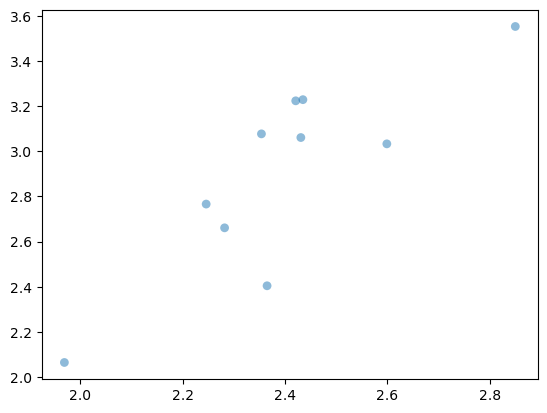

In [21]:
fig, ax = plt.subplots()

ax.scatter(
            garonne_clim_camels.loc[:, "p_mean"],
            garonne_clim_camels.loc[:, "cli_prec_mean"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)


In [22]:
garonne_clim_camels

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,nse_rand,bfi_obs,bfi_r1comp,bfi_c1comp,bfi_g1comp,bfi_nogeo,...,qmean_g1comp,qmean_nogeo,qmean_rand,p_mean,ele_mt_mean,gauge_name,t_mean,cli_prec_mean,cli_temp_mean,k_p
gauge_id,,,,,,,,,,,,,,,,,,,,,
O029531001,0.697635,0.711753,0.721948,0.708220,0.730121,0.539423,0.636402,0.574418,0.624012,0.624724,...,0.891340,0.893654,0.888284,2.365,411.430,O0295310,11.969463,2.40426,11.6,1.016600
O055401001,0.685334,0.699813,0.702822,0.696487,0.716126,0.556167,0.558764,0.573878,0.623942,0.630287,...,1.275334,1.260428,1.284879,2.599,671.291,O0554010,10.735842,3.03339,10.4,1.167137
O062401001,0.690960,0.723777,0.735273,0.684688,0.728631,0.456656,0.625720,0.496957,0.592440,0.598371,...,0.802795,0.799003,0.802478,2.246,475.752,O0624010,11.858859,2.76643,11.5,1.231714
O158461001,0.730333,0.780502,0.776030,0.777302,0.721376,0.465276,0.508776,0.506442,0.546681,0.595770,...,1.271059,1.274727,1.288056,2.282,559.939,O1584610,11.554390,2.66111,11.4,1.166131
O023402001,0.540437,0.498590,0.568121,0.574346,0.452339,0.655594,0.667265,0.698444,0.594348,0.612460,...,1.832182,1.835464,1.834416,2.850,1035.152,Le Ger Ã Aspet [2],9.110264,3.55368,8.9,1.246905
O074404001,0.744501,0.740654,0.719153,0.698710,0.710849,0.560217,0.700905,0.663441,0.641699,0.634061,...,1.088775,1.087034,1.097173,2.354,579.685,L'Arize au Mas-d'Azil,11.157343,3.07764,10.9,1.307409
O144291002,0.716092,0.714494,0.731857,0.684775,0.731311,0.652251,0.570153,0.609677,0.615154,0.619351,...,1.424509,1.402036,1.436035,2.421,1063.854,Le Grand Hers Ã Laroque-d'Olmes et au Peyrat,9.219512,3.22417,9.0,1.331751
O149431003,0.547683,0.544578,0.555606,0.554618,0.543674,0.603356,0.664012,0.677279,0.632744,0.594153,...,1.528955,1.531695,1.533939,2.435,1097.040,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,8.625799,3.22927,8.8,1.326189
O149433001,0.657394,0.671578,0.682339,0.673129,0.667721,0.617747,0.654277,0.634912,0.626415,0.619819,...,1.425873,1.402899,1.423393,2.431,940.039,Le Touyre Ã LÃ©ran,9.467105,3.06138,9.5,1.259309


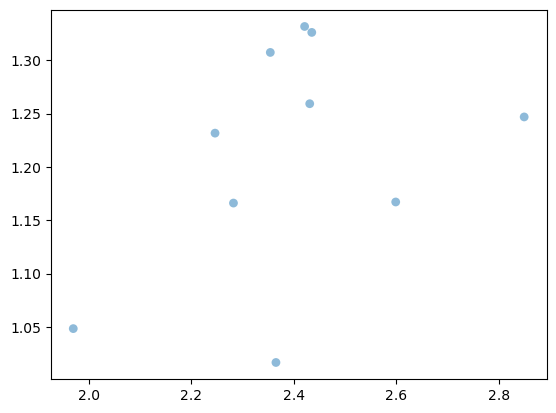

In [23]:
fig, ax = plt.subplots()

ax.scatter(
            garonne_clim_camels.loc[:, "p_mean"],
            garonne_clim_camels.loc[:, "k_p"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)


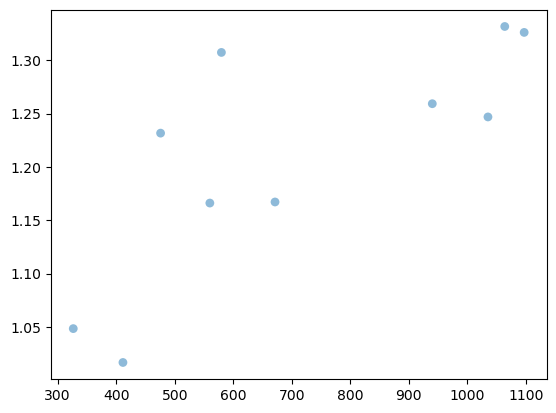

In [ ]:
fig, ax = plt.subplots()

ax.scatter(
            garonne_clim_camels.loc[:, "ele_mt_mean"],
            garonne_clim_camels.loc[:, "k_p"],
            s=40,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1)

In [25]:
import numpy as np

# extract vectors
z = garonne_clim_camels["ele_mt_mean"].values
k = garonne_clim_camels["k_p"].values

# safety: remove invalid entries
mask = np.isfinite(z) & np.isfinite(k) & (k > 0)
z = z[mask]
k = k[mask]

# fit log(k) = a + b * z
y = np.log(k)

b = np.cov(z, y, ddof=1)[0, 1] / np.var(z, ddof=1)
a = y.mean() - b * z.mean()

print(f"log(k_p) = {a:.4f} + {b:.6e} * elevation")


log(k_p) = 0.0107 + 2.459830e-04 * elevation


R² (exponential model) = 0.580


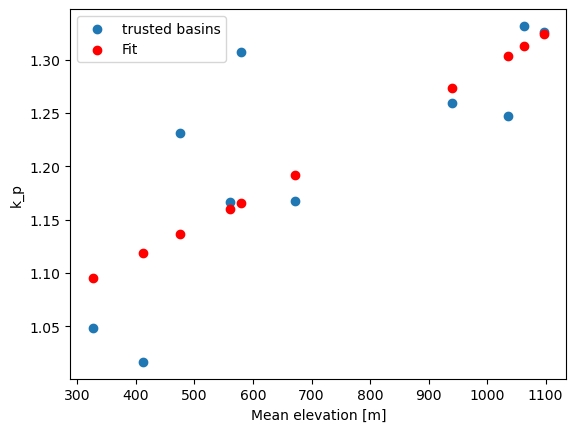

In [26]:
import numpy as np

z = garonne_clim_camels["ele_mt_mean"].values
k = garonne_clim_camels["k_p"].values

mask = np.isfinite(z) & np.isfinite(k) & (k > 0)
z = z[mask]
k = k[mask]

y = np.log(k)

# exponential (log-linear) fit
b1 = np.cov(z, y, ddof=1)[0, 1] / np.var(z, ddof=1)
a1 = y.mean() - b1 * z.mean()
y_hat_1 = a1 + b1 * z

# R²
ss_res = np.sum((y - y_hat_1)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_exp = 1 - ss_res / ss_tot

print(f"R² (exponential model) = {r2_exp:.3f}")


plt.scatter(z, k, label="trusted basins")
plt.scatter(z, np.exp(y_hat_1), color="red", label="Fit")
plt.xlabel("Mean elevation [m]")
plt.ylabel("k_p")
plt.legend()
plt.show()


In [27]:
garonne_clim["k_pre"] = np.exp(0.0107 + 2.459830e-04 * garonne_clim["ele_mt_mean"])
garonne_clim

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,nse_rand,bfi_obs,bfi_r1comp,bfi_c1comp,bfi_g1comp,bfi_nogeo,...,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_rand,p_mean,ele_mt_mean,gauge_name,gauge_id,t_mean,k_pre
basin_id,,,,,,,,,,,,,,,,,,,,,
FR001526,0.697635,0.711753,0.721948,0.708220,0.730121,0.539423,0.636402,0.574418,0.624012,0.624724,...,0.897051,0.891340,0.893654,0.888284,2.365,411.430,O0295310,O029531001,11.969463,1.118406
FR001544,0.685334,0.699813,0.702822,0.696487,0.716126,0.556167,0.558764,0.573878,0.623942,0.630287,...,1.291152,1.275334,1.260428,1.284879,2.599,671.291,O0554010,O055401001,10.735842,1.192231
FR001545,0.532401,0.571522,0.600773,0.594959,0.568257,0.665813,0.720151,0.726059,0.662893,0.606422,...,1.633660,1.604206,1.607367,1.592081,2.689,981.246,O0592510,O059251001,9.334658,1.286686
FR001547,0.690960,0.723777,0.735273,0.684688,0.728631,0.456656,0.625720,0.496957,0.592440,0.598371,...,0.827132,0.802795,0.799003,0.802478,2.246,475.752,O0624010,O062401001,11.858859,1.136243
FR001551,0.807297,0.804728,0.779917,0.797104,0.798207,0.522667,0.647090,0.660937,0.637372,0.633185,...,1.003261,0.996531,0.999466,1.003070,2.276,454.496,O0794010,O079401001,11.832177,1.130317
FR001577,0.730333,0.780502,0.776030,0.777302,0.721376,0.465276,0.508776,0.506442,0.546681,0.595770,...,1.298150,1.271059,1.274727,1.288056,2.282,559.939,O1584610,O158461001,11.554390,1.160018
FR001584,0.555362,0.658044,0.669173,0.720698,0.647477,0.727093,0.697358,0.674785,0.663347,0.609305,...,1.338965,1.400792,1.402904,1.402468,2.530,896.438,O1900010,O200001001,9.854757,1.260122
FR001592,0.599182,0.628271,0.581224,0.577934,0.606372,0.535970,0.501810,0.502028,0.579064,0.596078,...,0.535676,0.523991,0.516249,0.523112,1.802,210.916,O2215010,O221501001,13.181370,1.064581
FR001593,0.742057,0.774654,0.743754,0.716541,0.762697,0.561716,0.507700,0.520707,0.604190,0.597269,...,0.505555,0.543910,0.536345,0.543959,1.822,221.214,O2222510,O222251001,13.250151,1.067282


In [28]:
garonne_clim[["nse_r1comp", "k_pre"]].corr(method="spearman")

,nse_r1comp,k_pre
nse_r1comp,1.000000,-0.223038
k_pre,-0.223038,1.000000


In [29]:
garonne_clim[["k_pre", "nse_r1comp", "nse_g1comp"]]

,k_pre,nse_r1comp,nse_g1comp
basin_id,,,
FR001526,1.118406,0.708220,0.711753
FR001544,1.192231,0.696487,0.699813
FR001545,1.286686,0.594959,0.571522
FR001547,1.136243,0.684688,0.723777
FR001551,1.130317,0.797104,0.804728
FR001577,1.160018,0.777302,0.780502
FR001584,1.260122,0.720698,0.658044
FR001592,1.064581,0.577934,0.628271
FR001593,1.067282,0.716541,0.774654


In [30]:
garonne_clim

,nse_nogeo,nse_g1comp,nse_c1comp,nse_r1comp,nse_rand,bfi_obs,bfi_r1comp,bfi_c1comp,bfi_g1comp,bfi_nogeo,...,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_rand,p_mean,ele_mt_mean,gauge_name,gauge_id,t_mean,k_pre
basin_id,,,,,,,,,,,,,,,,,,,,,
FR001526,0.697635,0.711753,0.721948,0.708220,0.730121,0.539423,0.636402,0.574418,0.624012,0.624724,...,0.897051,0.891340,0.893654,0.888284,2.365,411.430,O0295310,O029531001,11.969463,1.118406
FR001544,0.685334,0.699813,0.702822,0.696487,0.716126,0.556167,0.558764,0.573878,0.623942,0.630287,...,1.291152,1.275334,1.260428,1.284879,2.599,671.291,O0554010,O055401001,10.735842,1.192231
FR001545,0.532401,0.571522,0.600773,0.594959,0.568257,0.665813,0.720151,0.726059,0.662893,0.606422,...,1.633660,1.604206,1.607367,1.592081,2.689,981.246,O0592510,O059251001,9.334658,1.286686
FR001547,0.690960,0.723777,0.735273,0.684688,0.728631,0.456656,0.625720,0.496957,0.592440,0.598371,...,0.827132,0.802795,0.799003,0.802478,2.246,475.752,O0624010,O062401001,11.858859,1.136243
FR001551,0.807297,0.804728,0.779917,0.797104,0.798207,0.522667,0.647090,0.660937,0.637372,0.633185,...,1.003261,0.996531,0.999466,1.003070,2.276,454.496,O0794010,O079401001,11.832177,1.130317
FR001577,0.730333,0.780502,0.776030,0.777302,0.721376,0.465276,0.508776,0.506442,0.546681,0.595770,...,1.298150,1.271059,1.274727,1.288056,2.282,559.939,O1584610,O158461001,11.554390,1.160018
FR001584,0.555362,0.658044,0.669173,0.720698,0.647477,0.727093,0.697358,0.674785,0.663347,0.609305,...,1.338965,1.400792,1.402904,1.402468,2.530,896.438,O1900010,O200001001,9.854757,1.260122
FR001592,0.599182,0.628271,0.581224,0.577934,0.606372,0.535970,0.501810,0.502028,0.579064,0.596078,...,0.535676,0.523991,0.516249,0.523112,1.802,210.916,O2215010,O221501001,13.181370,1.064581
FR001593,0.742057,0.774654,0.743754,0.716541,0.762697,0.561716,0.507700,0.520707,0.604190,0.597269,...,0.505555,0.543910,0.536345,0.543959,1.822,221.214,O2222510,O222251001,13.250151,1.067282


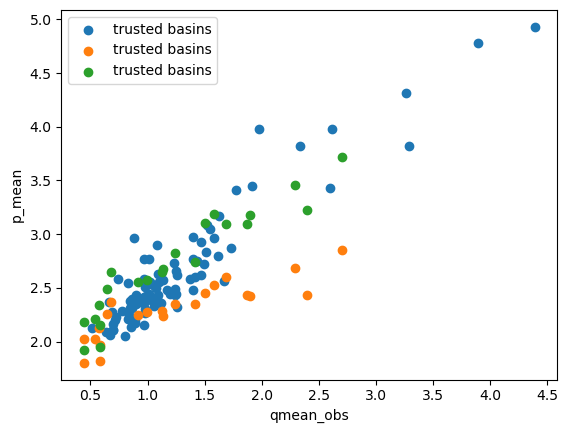

In [31]:
plt.scatter(moselle_clim["qmean_obs"], moselle_clim["p_mean"], label="trusted basins")

plt.scatter(garonne_clim["qmean_obs"], garonne_clim["p_mean"], label="trusted basins")

plt.scatter(garonne_clim["qmean_obs"], garonne_clim["k_pre"]*garonne_clim["p_mean"], label="trusted basins")
plt.xlabel("qmean_obs")
plt.ylabel("p_mean")
plt.legend()
plt.show()


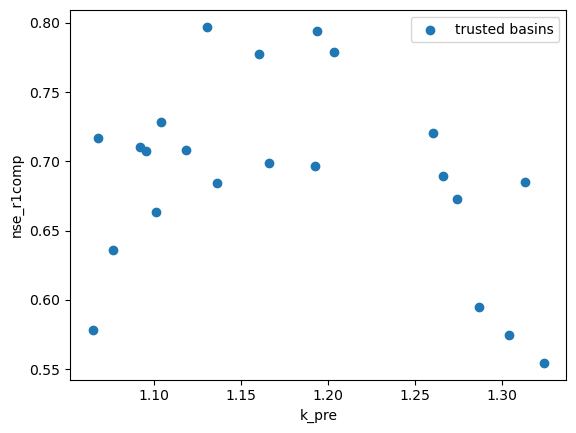

In [32]:
plt.scatter(garonne_clim["k_pre"], garonne_clim["nse_r1comp"], label="trusted basins")
plt.xlabel("k_pre")
plt.ylabel("nse_r1comp")
plt.legend()
plt.show()


In [35]:
catchments_garonne_ids = garonne_clim.index.tolist()
catchments_garonne_ids

['FR001526',
 'FR001544',
 'FR001545',
 'FR001547',
 'FR001551',
 'FR001577',
 'FR001584',
 'FR001592',
 'FR001593',
 'FR001604',
 'FR004091',
 'FR004114',
 'FR004119',
 'FR004132',
 'FR004133',
 'FR004136',
 'FR004137',
 'FR004140',
 'FR004143',
 'FR004149',
 'FR004152',
 'FR004162']

In [38]:
garonne_clim.to_csv("../results/precipitation_correction/garonne_clim_with_kpre.csv")

In [ ]:
# Initialize the dictionary
inputs = {}
observations = {}
areas = {}
perm_areas = {}
quality_masks = {}
rootdepth_mean = {}
waterdeficit_mean = {}
perm_areasglobal = {}
perm_areascontinental = {}
prec_mean = {}

catchments_garonne_ids = garonne_clim.index.tolist()

# Function to compute S_dem per water year
def compute_S_dem(group):
    group = group.copy()
    group.iloc[0, group.columns.get_loc('S_dem(t-1)')] = 0
    group.iloc[0, group.columns.get_loc('S_dem(t)')] = max(
        0, group.iloc[0]['S_dem(t-1)'] + (group.iloc[0]['pet_mean'] - group.iloc[0]['p_mean'])
    )

    for i in range(1, len(group)):
        group.iloc[i, group.columns.get_loc('S_dem(t-1)')] = group.iloc[i - 1]['S_dem(t)']
        group.iloc[i, group.columns.get_loc('S_dem(t)')] = max(
            0, group.iloc[i]['S_dem(t-1)'] + (group.iloc[i]['pet_mean'] - group.iloc[i]['p_mean'])
        )

    return group


for basin_id in tqdm.tqdm(catchments_garonne_ids):
    k_p = garonne_clim.loc[basin_id, "k_pre"]
    print(k_p)

    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

    area = network_estreams.loc[basin_id, "area_estreams"]
    
    data["Q"] = data.loc[:, "q_mean"]
    data["Q"] = (data.Q * 86400 * 1000) / (area * 1000000)

    # Define the subset to be used:
    #data = data.loc["1988":"2001", :]
    data = data.loc["2000-10-01":"2015-09-30"]


    # Interpolate when needed:
    data['pet_mean'] = data['pet_mean'].interpolate()
    data['t_mean'] = data['t_mean'].interpolate()
    data['p_mean'] = data['p_mean'].interpolate()

    data['p_mean'] = data['p_mean'] * k_p

    data_wd = data.copy()
    data_wd.index = pd.to_datetime(data_wd.index)

    # Define water year (Oct 1 to Sept 30)

    data_wd['water_year'] = np.where(data_wd.index.month >= 10, data_wd.index.year + 1, data_wd.index.year)
    data_wd['S_dem(t-1)'] = np.nan
    data_wd['S_dem(t)'] = np.nan

    ## Apply computation per water year
    data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
    
    # Compute the 75% quantile of 'S_dem(t)' per water year
    S_dem_75_per_year = data_wd.groupby('water_year')['S_dem(t)'].max()
    S_dem_75_per_year = S_dem_75_per_year.quantile(0.75)

    # Save the variables:
    Q_obs = data.loc[:, "Q"].values
    P = data.loc[:, "p_mean"].values
    E = data.loc[:, "pet_mean"].values
    T = data.loc[:, "t_mean"].values
    quality =  (pd.isna(Q_obs)).astype(int)

    inputs[basin_id] = [P, T, E]
    observations[basin_id] = Q_obs
    areas[basin_id] = area
    perm_areas[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_regi"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_regi"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_regi"] / 100, 2)]
    
    perm_areasglobal[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_glob2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_glob2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_glob2"] / 100, 2)]
    
    perm_areascontinental[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_cont2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_cont2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_cont2"] / 100, 2)]

    quality_masks[basin_id] = quality
    rootdepth_mean[basin_id] = estreams_attributes_garonne.loc[basin_id, "root_dep_mean"]
    waterdeficit_mean[basin_id] = np.float64(round(S_dem_75_per_year, 1))
    prec_mean[basin_id] = estreams_attributes_garonne.loc[basin_id, "p_mean"]

  0%|          | 0/22 [00:00<?, ?it/s]

1.118406367284719


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/3706462493.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  5%|▍         | 1/22 [00:01<00:22,  1.07s/it]

1.192230799989874


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/3706462493.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  9%|▉         | 2/22 [00:02<00:21,  1.09s/it]

...

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/3706462493.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
 91%|█████████ | 20/22 [00:26<00:02,  1.38s/it]

1.0917908833764787


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/3706462493.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
 95%|█████████▌| 21/22 [00:28<00:01,  1.36s/it]

1.0760254775416942


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/3706462493.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
100%|██████████| 22/22 [00:29<00:00,  1.34s/it]


In [11]:
import numpy as np
import os as os
# Number of random versions you want
n_random_sets = 2

# Number of components (high, medium, low)
n_components = 3

# Initialize the containers
perm_areas_random = {}

# Save the dictionaries
path_inputs1 = r'../data/models/inputgaronne/subset_2001_2015'

path_inputs2 = r'../data/models/inputgaronne/subset_1988_2001'


# Loop through each random set
for i in range(1, n_random_sets + 1):
    seed = 100 + i  # you can choose your own seed pattern
    np.random.seed(seed)

    perm_dict = {}
    for basin_id in catchments_garonne_ids:
        # Generate 3 random positive numbers
        r = np.random.rand(n_components)
        # Normalize to make them sum to 1
        r = r / r.sum()
        # Round if you want consistent formatting (e.g., 2 decimals)
        perm_dict[basin_id] = np.round(r, 2).tolist()

    # Save to a named variable like perm_areas_random01, etc.
    perm_areas_random[f'perm_areas_random{i:02d}'] = perm_dict
    
    # Save dictionary as .npy
    np.save(os.path.join(path_inputs1, f'perm_areas_random{i:02d}.npy'), perm_dict)
    np.save(os.path.join(path_inputs2, f'perm_areas_random{i:02d}.npy'), perm_dict)

In [98]:
# Save the dictionaries
path_inputs = r'../data/models/inputgaronne/subset_2001_2015'

np.save(path_inputs+'//inputs.npy', inputs)
np.save(path_inputs+'//observations.npy', observations)
np.save(path_inputs+'//areas.npy', areas)
np.save(path_inputs+'//perm_areas.npy', perm_areas)
np.save(path_inputs+'//quality_masks.npy', quality_masks)
np.save(path_inputs+'//rootdepth_mean.npy', rootdepth_mean)
np.save(path_inputs+'//waterdeficit_mean.npy', waterdeficit_mean)
np.save(path_inputs+'//perm_areasglobal.npy', perm_areasglobal)
np.save(path_inputs+'//perm_areascontinental.npy', perm_areascontinental)
np.save(path_inputs+'//prec_mean.npy', prec_mean)

In [99]:
# Initialize the dictionary
inputs = {}
observations = {}
areas = {}
perm_areas = {}
quality_masks = {}
rootdepth_mean = {}
waterdeficit_mean = {}
perm_areasglobal = {}
perm_areascontinental = {}
prec_mean = {}

# Function to compute S_dem per water year
def compute_S_dem(group):
    group = group.copy()
    group.iloc[0, group.columns.get_loc('S_dem(t-1)')] = 0
    group.iloc[0, group.columns.get_loc('S_dem(t)')] = max(
        0, group.iloc[0]['S_dem(t-1)'] + (group.iloc[0]['pet_mean'] - group.iloc[0]['p_mean'])
    )

    for i in range(1, len(group)):
        group.iloc[i, group.columns.get_loc('S_dem(t-1)')] = group.iloc[i - 1]['S_dem(t)']
        group.iloc[i, group.columns.get_loc('S_dem(t)')] = max(
            0, group.iloc[i]['S_dem(t-1)'] + (group.iloc[i]['pet_mean'] - group.iloc[i]['p_mean'])
        )

    return group


for basin_id in tqdm.tqdm(catchments_garonne_ids):
    k_p = garonne_clim.loc[basin_id, "k_pre"]
    print(k_p)
    
    data = pd.read_csv(path_estreams+"/time_series_csv/estreams_timeseries_"+basin_id+".csv", index_col=0)

    area = network_estreams.loc[basin_id, "area_estreams"]

    data["Q"] = data.loc[:, "q_mean"]
    data["Q"] = (data.Q * 86400 * 1000) / (area * 1000000)

    # Define the subset to be used:
    data = data.loc["1988-10-01":"2001-09-30", :]
    #data = data.loc["2000-10-01":"2015-09-30"]


    # Interpolate when needed:
    data['pet_mean'] = data['pet_mean'].interpolate()
    data['t_mean'] = data['t_mean'].interpolate()
    data['p_mean'] = data['p_mean'].interpolate()

    data['p_mean'] = data['p_mean'] * k_p

    data_wd = data.copy()
    data_wd.index = pd.to_datetime(data_wd.index)

    # Define water year (Oct 1 to Sept 30)

    data_wd['water_year'] = np.where(data_wd.index.month >= 10, data_wd.index.year + 1, data_wd.index.year)
    data_wd['S_dem(t-1)'] = np.nan
    data_wd['S_dem(t)'] = np.nan

    ## Apply computation per water year
    data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
    
    # Compute the 75% quantile of 'S_dem(t)' per water year
    S_dem_75_per_year = data_wd.groupby('water_year')['S_dem(t)'].max()
    S_dem_75_per_year = S_dem_75_per_year.quantile(0.75)

    # Save the variables:
    Q_obs = data.loc[:, "Q"].values
    P = data.loc[:, "p_mean"].values
    E = data.loc[:, "pet_mean"].values
    T = data.loc[:, "t_mean"].values
    quality =  (pd.isna(Q_obs)).astype(int)

    inputs[basin_id] = [P, T, E]
    observations[basin_id] = Q_obs
    areas[basin_id] = area
    perm_areas[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_regi"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_regi"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_regi"] / 100, 2)]
    
    perm_areasglobal[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_glob2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_glob2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_glob2"] / 100, 2)]
    
    perm_areascontinental[basin_id] = [round(estreams_attributes_garonne.loc[basin_id, "perm_high_cont2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_medium_cont2"] / 100, 2), 
                            round(estreams_attributes_garonne.loc[basin_id, "perm_low_cont2"] / 100, 2)]

    quality_masks[basin_id] = quality
    rootdepth_mean[basin_id] = estreams_attributes_garonne.loc[basin_id, "root_dep_mean"]
    waterdeficit_mean[basin_id] = np.float64(round(S_dem_75_per_year, 1))
    prec_mean[basin_id] = estreams_attributes_garonne.loc[basin_id, "p_mean"]

  0%|          | 0/22 [00:00<?, ?it/s]

1.118406367284719


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/406864589.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  5%|▍         | 1/22 [00:00<00:18,  1.11it/s]

1.192230799989874


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/406864589.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
  9%|▉         | 2/22 [00:01<00:20,  1.01s/it]

...

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/406864589.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
 91%|█████████ | 20/22 [00:23<00:02,  1.19s/it]

1.0917908833764787


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/406864589.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
 95%|█████████▌| 21/22 [00:24<00:01,  1.14s/it]

1.0760254775416942


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_78483/406864589.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_wd = data_wd.groupby('water_year', group_keys=False).apply(compute_S_dem)
100%|██████████| 22/22 [00:25<00:00,  1.18s/it]


In [101]:
# Save the dictionaries
path_inputs = r'../data/models/inputgaronne/subset_1988_2001'

np.save(path_inputs+'//inputs.npy', inputs)
np.save(path_inputs+'//observations.npy', observations)
np.save(path_inputs+'//areas.npy', areas)
np.save(path_inputs+'//perm_areas.npy', perm_areas)
np.save(path_inputs+'//quality_masks.npy', quality_masks)
np.save(path_inputs+'//rootdepth_mean.npy', rootdepth_mean)
np.save(path_inputs+'//waterdeficit_mean.npy', waterdeficit_mean)
np.save(path_inputs+'//perm_areasglobal.npy', perm_areasglobal)
np.save(path_inputs+'//perm_areascontinental.npy', perm_areascontinental)
np.save(path_inputs+'//prec_mean.npy', prec_mean)

## End